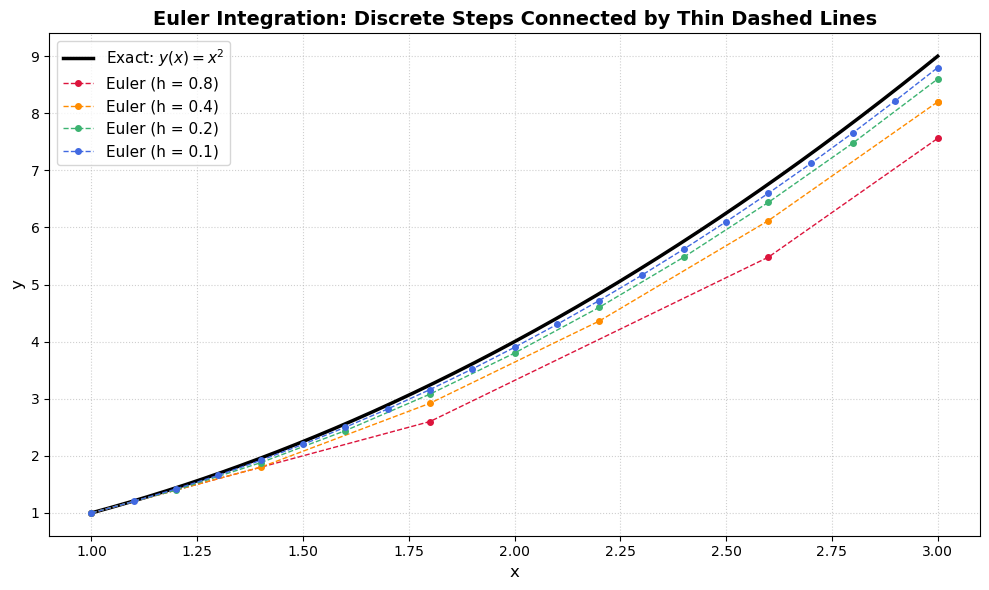

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# USER CONFIGURATION
# ==========================================
# ODE Right-Hand Side: dy/dx = f(x, y) = 2*x
def f(x, y):
    return 2 * x

# Exact Analytical Solution: y(x) = x^2
def y_exact(x):
    return x**2

# Initial condition (x0, y0) = (1, 1) and integration domain
x0 = 1.0
y0 = 1.0
x_end = 3.0

# Step sizes to compare (from coarse to fine)
step_sizes = [0.8, 0.4, 0.2, 0.1]
# ==========================================

def euler_integrate(f, x0, y0, x_end, h):
    x_vals = [x0]
    y_vals = [y0]
    x_curr = x0
    y_curr = y0
    
    while x_curr < x_end:
        step = min(h, x_end - x_curr)
        y_curr = y_curr + step * f(x_curr, y_curr)
        x_curr = x_curr + step
        x_vals.append(x_curr)
        y_vals.append(y_curr)
        
    return np.array(x_vals), np.array(y_vals)

# Setup Figure
plt.figure(figsize=(10, 6))

# 1. Continuous Black Line for Exact Solution
x_dense = np.linspace(x0, x_end, 500)
plt.plot(x_dense, y_exact(x_dense), 'k-', linewidth=2.5, label='Exact: $y(x) = x^2$')

# 2. Discrete Points Connected by Thin Dashed Lines
colors = ['crimson', 'darkorange', 'mediumseagreen', 'royalblue']

for idx, h in enumerate(step_sizes):
    x_num, y_num = euler_integrate(f, x0, y0, x_end, h)
    plt.plot(
        x_num, 
        y_num, 
        linestyle='--', 
        linewidth=1.0, 
        marker='o', 
        markersize=4, 
        color=colors[idx % len(colors)], 
        label=f'Euler (h = {h})'
    )

# Formatting
plt.title('Euler Integration: Discrete Steps Connected by Thin Dashed Lines', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()